## Problem Statemente
> We are working on a project to predict sales at Rossmann's [Rossmann Store Sales](https://www.kaggle.com/c/rossmann-store-sales), a popular retail chain. The goal is to build a deep learning model using a multi-layer Dense Neural Network to analyze daily sales data and the influence of various factors such as promotions, holidays, and location.
>> 
Using TensorFlow and Keras, I created a model with multiple hidden layers with ReLU activation functions, along with a predictive output layer to estimate sales valu-sales/data

# Information about the data
> Rossmann operates over 3,000 drug stores in 7 European countries. Currently, Rossmann store managers are tasked with predicting their daily sales for up to six weeks in advance. Store sales are influenced by many factors, including promotions, competition, school and state holidays, seasonality, and locality. 

> With thousands of individual managers predicting sales based on their unique circumstances, the accuracy of results can be quite varied. You are provided with historical sales data for 1,115 Rossmann stores. The task is to forecast the "Sales" column for the test set. Note that some stores in the dataset were temporarily closed for refurbishment.

> View and download the data here: https://www.kaggle.com/c/rossmann-store-sales/data

## Downloading the Data

We can download the dataset from Kaggle directly within the Jupyter notebook using the `opendatasets` library. Make sure to [accept the competition rules](https://www.kaggle.com/c/rossmann-store-sales/rules) before executing the following cell.

In [1]:
import os
import opendatasets as od
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

In [5]:
od.download('https://www.kaggle.com/c/rossmann-store-sales')

Skipping, found downloaded files in ".\rossmann-store-sales" (use force=True to force download)


You'll be asked to provide your Kaggle credentials to download the data. Follow these instructions: http://bit.ly/kaggle-creds

In [5]:
os.listdir('rossmann-store-sales')

['store.csv',
 'submission.csv',
 'submission_df_XGboost.csv',
 'test.csv',
 'train.csv']

In [7]:
ross_df = pd.read_csv('./rossmann-store-sales/train.csv', low_memory=False)
store_df = pd.read_csv('./rossmann-store-sales/store.csv')
test_df = pd.read_csv('./rossmann-store-sales/test.csv')
submission_df = pd.read_csv('./rossmann-store-sales/submission.csv')

In [8]:
ross_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [11]:
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [13]:
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


# Merge store data with test and training data

In [16]:
merged_df = ross_df.merge(store_df, how='left', on='Store')
merged_test_df = test_df.merge(store_df, how='left', on='Store')

# exploratory data analysis and visualization

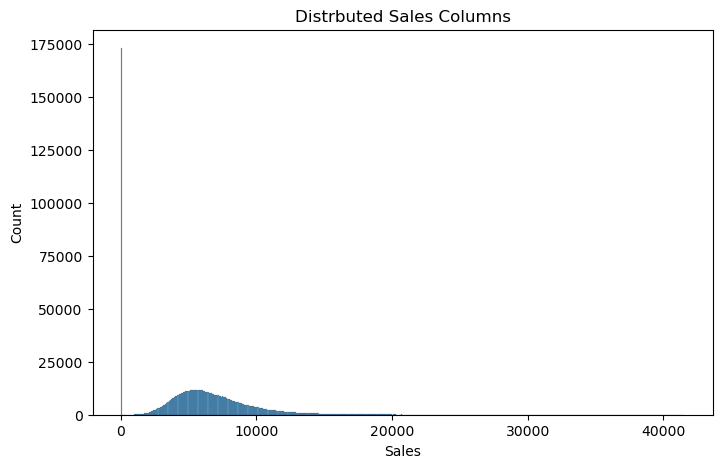

In [18]:
plt.figure(figsize = (8, 5))
plt.title('Distrbuted Sales Columns')
sns.histplot(data = merged_df, x = 'Sales')
plt.show()
#  النماذج الخطيه صعب ان تتعلم من هذا التوزيع

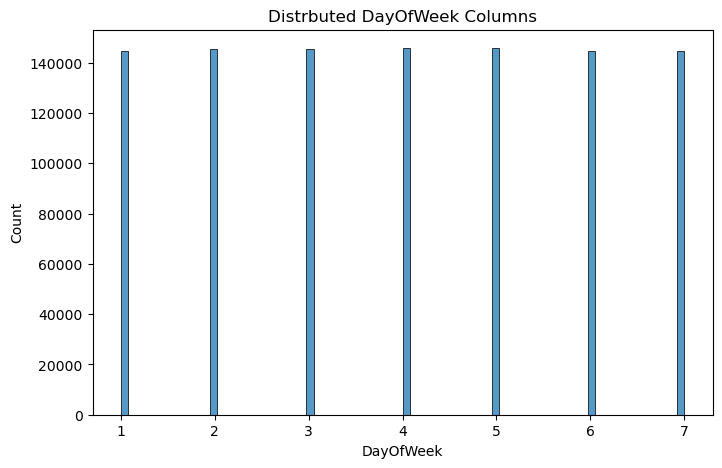

In [19]:
plt.figure(figsize = (8, 5))
plt.title('Distrbuted DayOfWeek Columns')
sns.histplot(data = merged_df, x = 'DayOfWeek')
plt.show()

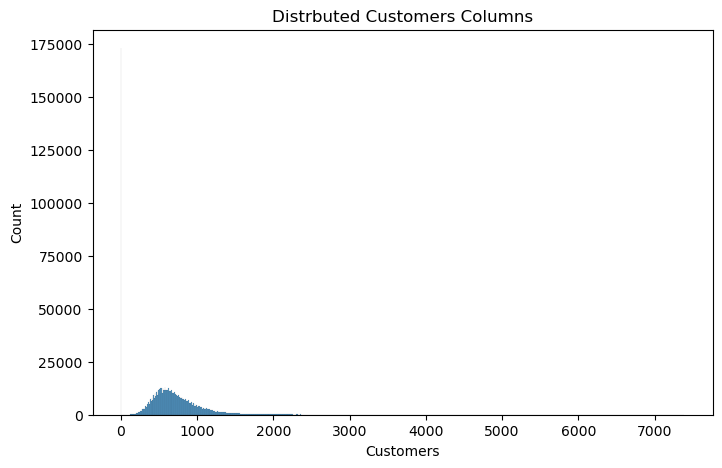

In [20]:
plt.figure(figsize = (8, 5))
plt.title('Distrbuted Customers Columns')
sns.histplot(data = merged_df, x = 'Customers')
plt.show()

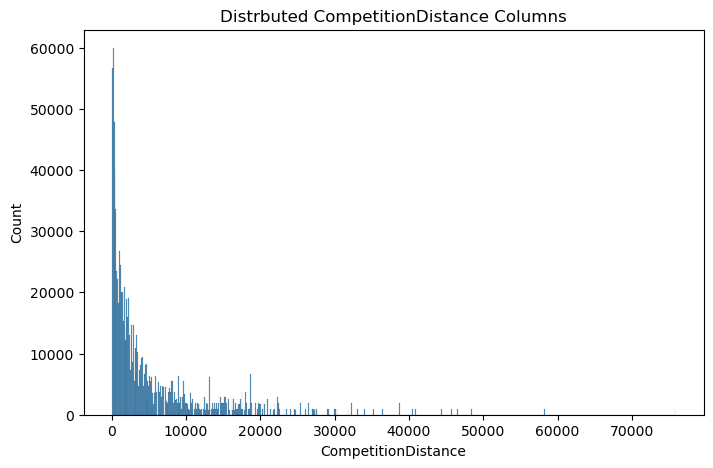

In [21]:
plt.figure(figsize = (8, 5))
plt.title('Distrbuted CompetitionDistance Columns')
sns.histplot(data = merged_df, x = 'CompetitionDistance')
plt.show()

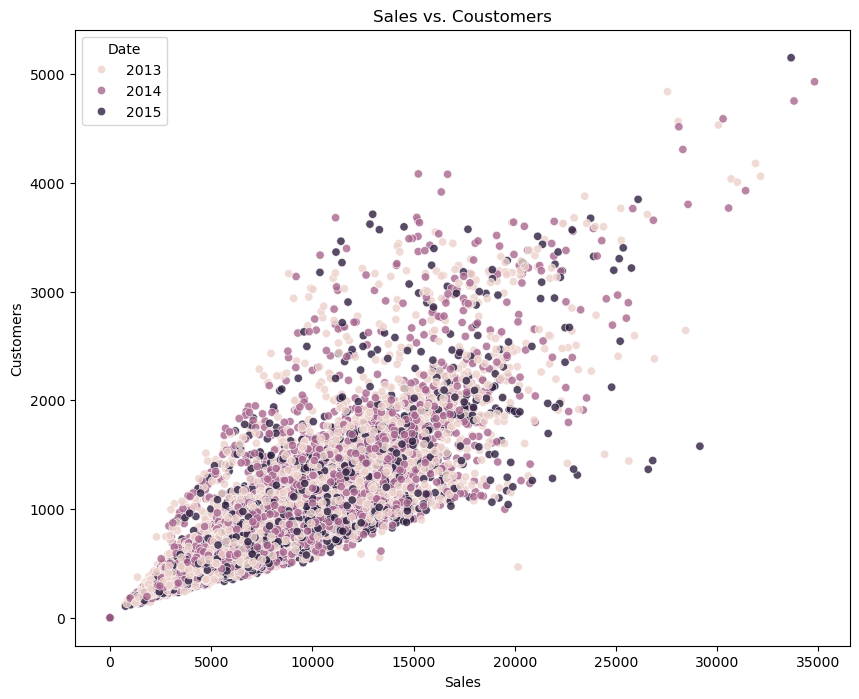

In [22]:
plt.figure(figsize = (10, 8))
temp_df = merged_df.sample(40000)
plt.title('Sales vs. Coustomers')
sns.scatterplot(data = temp_df, x = temp_df.Sales, y = temp_df.Customers, hue = pd.to_datetime(temp_df.Date).dt.year, alpha = 0.8)
plt.show()

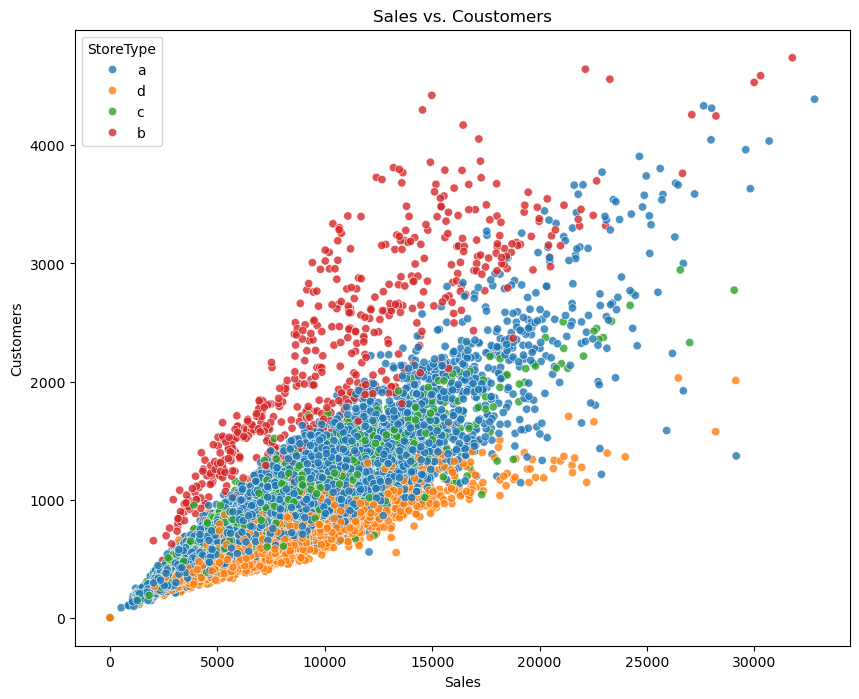

In [23]:
plt.figure(figsize = (10, 8))
temp_df = merged_df.sample(40000)
plt.title('Sales vs. Coustomers')
sns.scatterplot(data = temp_df, x = temp_df.Sales, y = temp_df.Customers, hue = 'StoreType', alpha = 0.8)
plt.show()

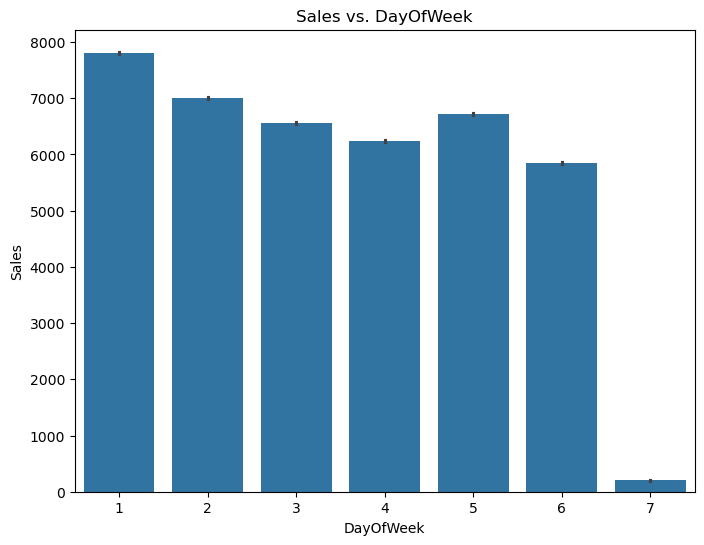

In [24]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.barplot(data = merged_df, x = 'DayOfWeek', y = 'Sales')
plt.show()

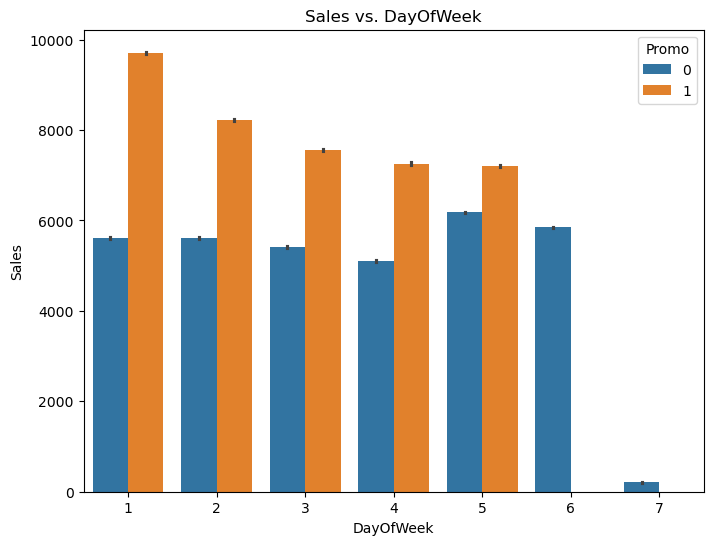

In [25]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.barplot(data = merged_df, x = 'DayOfWeek', y = 'Sales', hue = 'Promo')
plt.show()

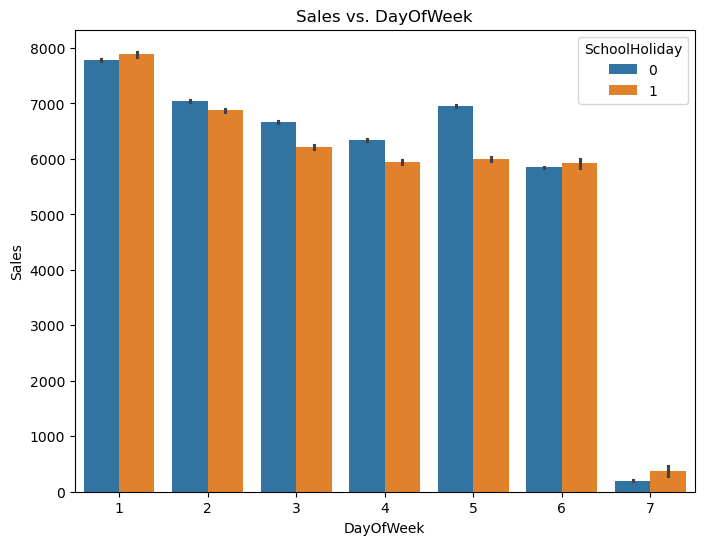

In [26]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.barplot(data = merged_df, x = 'DayOfWeek', y = 'Sales', hue = 'SchoolHoliday')
plt.show()

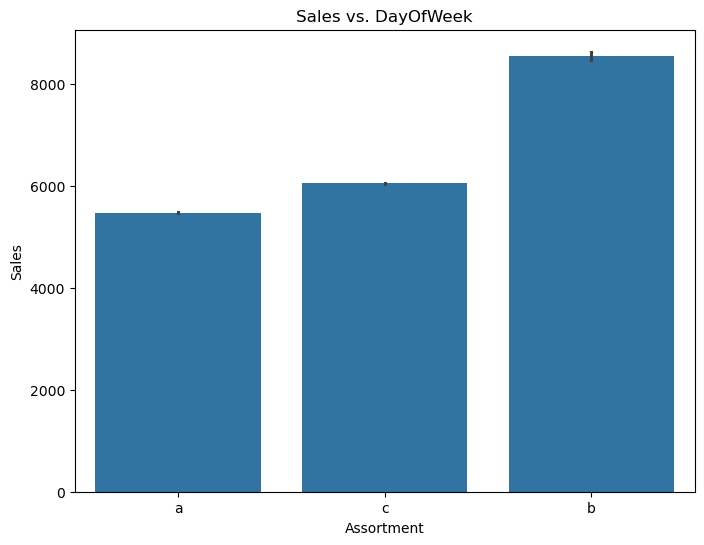

In [27]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.barplot(data = merged_df, x = 'Assortment', y = 'Sales')
plt.show()

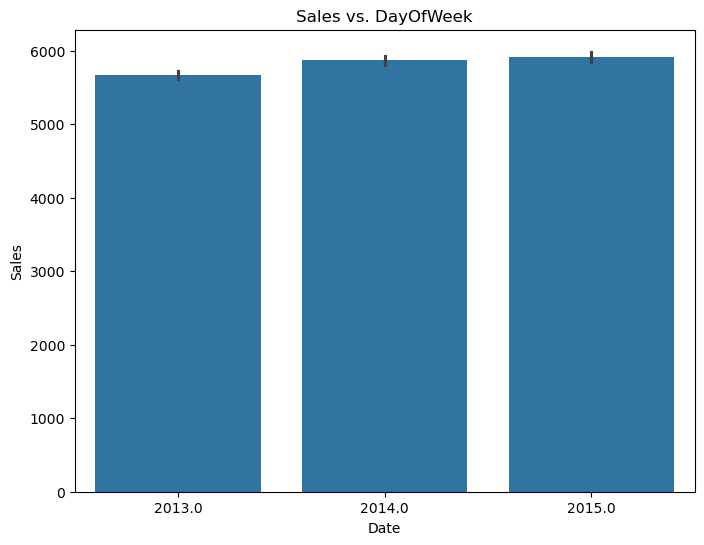

In [28]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.barplot(data = merged_df, x = pd.to_datetime(temp_df.Date).dt.year, y = 'Sales')
plt.show()

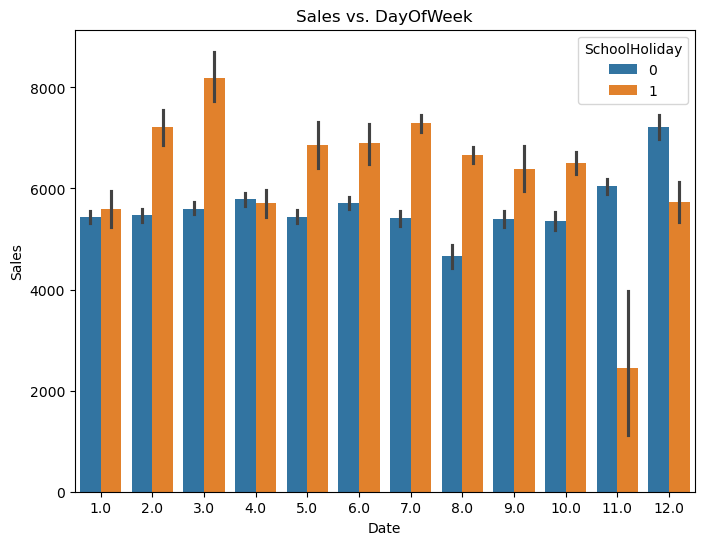

In [29]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.barplot(data = merged_df, x = pd.to_datetime(temp_df.Date).dt.month, y = 'Sales', hue ='SchoolHoliday' )
plt.show()

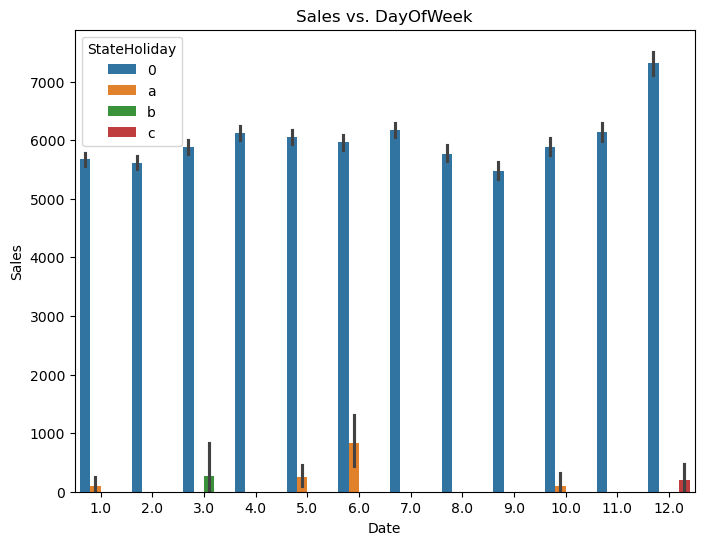

In [30]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.barplot(data = merged_df, x = pd.to_datetime(temp_df.Date).dt.month, y = 'Sales', hue = 'StateHoliday' )
plt.show()

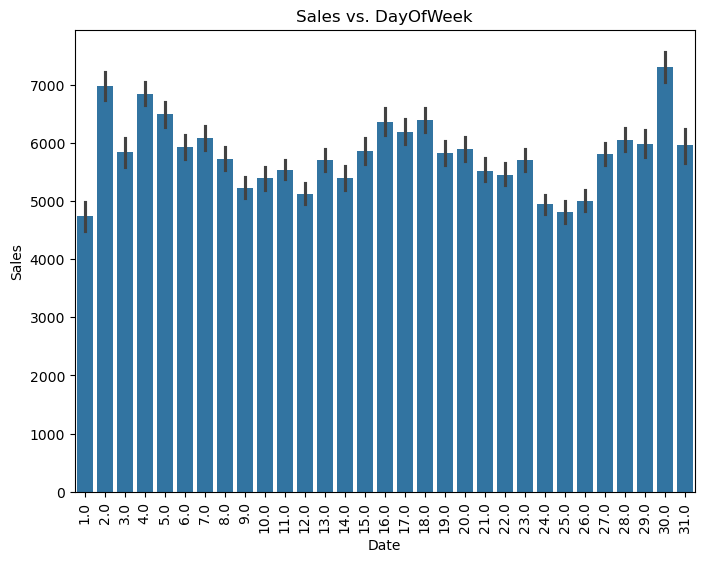

In [31]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.barplot(data = merged_df, x = pd.to_datetime(temp_df.Date).dt.day, y = 'Sales')
plt.xticks(rotation = 90)
plt.show()

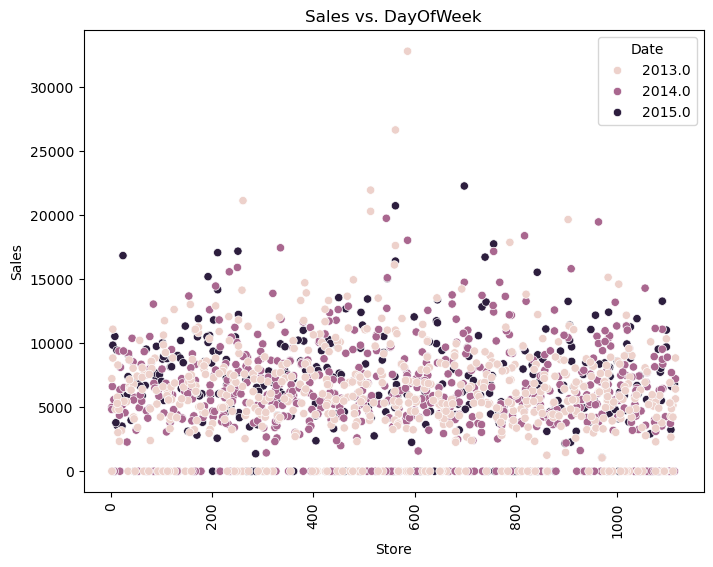

In [32]:
plt.figure(figsize = (8, 6))
plt.title('Sales vs. DayOfWeek')
sns.scatterplot(data = merged_df.sample(40000), x = 'Store', y = 'Sales',  hue = pd.to_datetime(temp_df.Date).dt.year)
plt.xticks(rotation = 90)
plt.show()

In [33]:
(pd.to_datetime(merged_df.Date).dt.year).unique

<bound method Series.unique of 0          2015
1          2015
2          2015
3          2015
4          2015
           ... 
1017204    2013
1017205    2013
1017206    2013
1017207    2013
1017208    2013
Name: Date, Length: 1017209, dtype: int32>

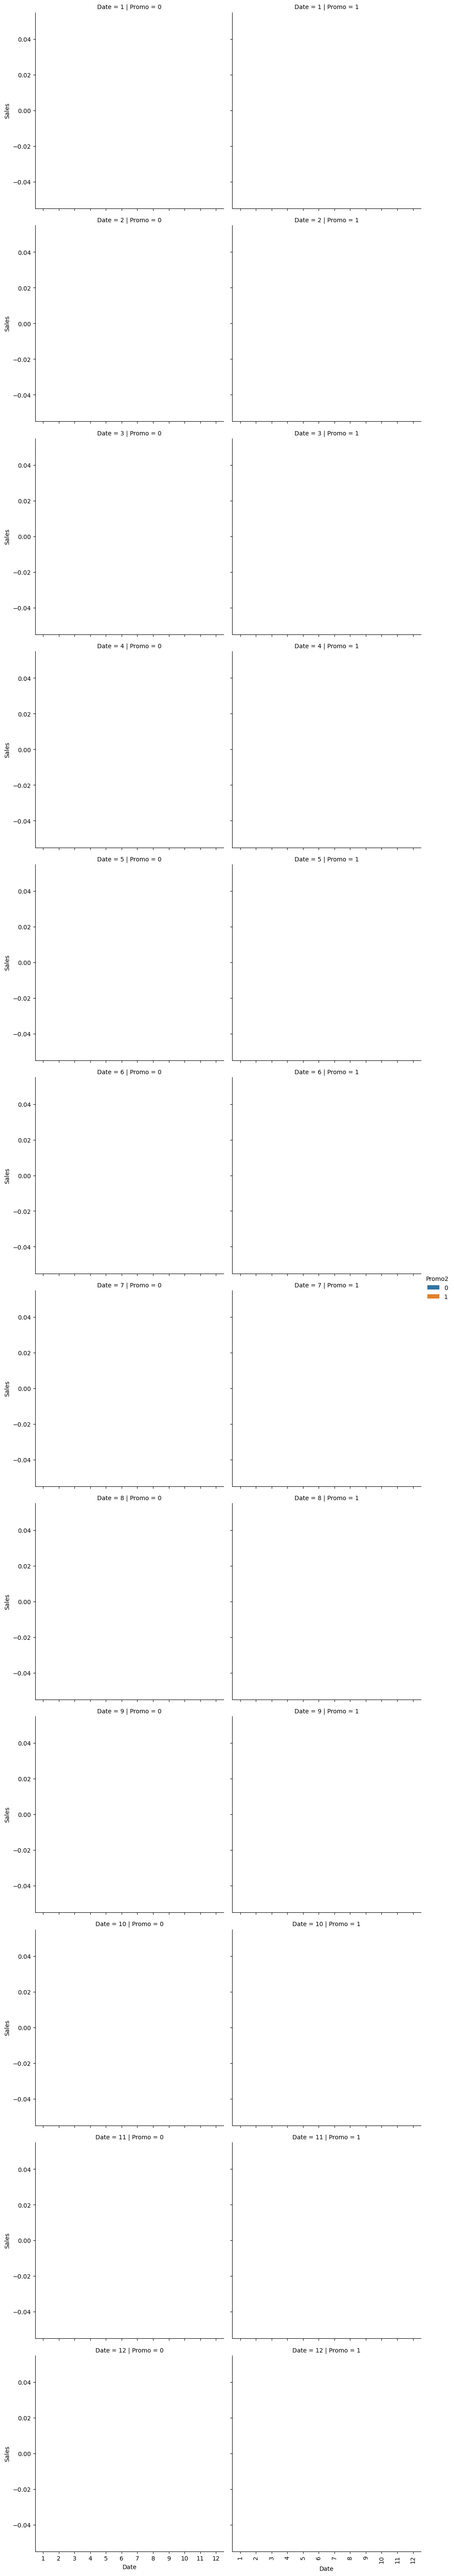

In [34]:
sns.catplot(kind='bar', data = merged_df, x=pd.to_datetime(merged_df.Date).dt.month, y='Sales', row=pd.to_datetime(merged_df.Date).dt.year , col='Promo', hue='Promo2')
plt.xticks(rotation = 90)
plt.show()

In [35]:
numeric_df = merged_df.select_dtypes(include = 'number')
merged_df_corr = numeric_df.corr()
merged_df_corr['Sales'].sort_values(ascending = False)

Sales                        1.000000
Customers                    0.894711
Open                         0.678472
Promo                        0.452345
SchoolHoliday                0.085124
Promo2SinceWeek              0.059558
CompetitionOpenSinceYear     0.012659
Store                        0.005126
CompetitionDistance         -0.019229
Promo2SinceYear             -0.021127
CompetitionOpenSinceMonth   -0.028257
Promo2                      -0.091040
DayOfWeek                   -0.462125
Name: Sales, dtype: float64

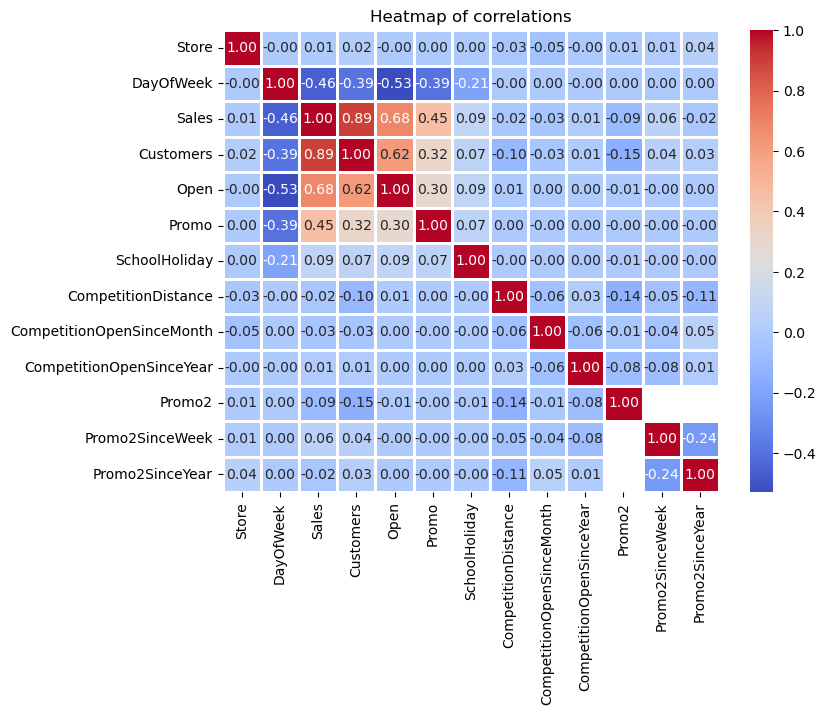

In [36]:
plt.figure(figsize = (8, 6))
plt.title('Heatmap of correlations')
sns.heatmap(data = merged_df_corr, annot = True, cmap = 'coolwarm', linewidths = 0.8, fmt='.2f')
plt.show()

## Preprocessing and Feature Engineering


لذلك، قد يكون عمود التاريخ مفيد جدًا في:

- تقسيم البيانات زمنياً: حتى لا يحدث تسريب للبيانات من المستقبل إلى الماضي أثناء التدريب والاختبار.  
- استخراج ميزات زمنية: مثل السنة، الشهر، اليوم، اليوم في الأسبوع، موسم السنة، وهكذا، مما قد يساعد النموذج على التعرف على الأنماط الموسمية أو الاتجاهات.  
- فهم تغيرات السوق أو العمليات عبر الزمن: قد تتغير الأنماط مع مرور الزمن، ومن المهم أن يأخذ نموذجك ذلك في الحسبان.

In [39]:
merged_df.info()
#  عامود التاريخ قد لا يفيدني لان جميع بيانات التدريب تنتمي الى التواريخ القديمه والاختبار للجديد

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO


### 1- Date

First, let's convert `Date` to a `datecolumn` and extract different parts of the date.

In [41]:
pd.to_datetime(merged_df['Date']).dt.isocalendar()

,year,week,day
0,2015,31,5
1,2015,31,5
2,2015,31,5
3,2015,31,5
4,2015,31,5
...,...,...,...
1017204,2013,1,2
1017205,2013,1,2
1017206,2013,1,2
1017207,2013,1,2


In [42]:
def split_date(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df.Date.dt.year
    df['Month'] = df.Date.dt.month
    df['Day'] = df.Date.dt.day
    df['WeekOfYear'] = df.Date.dt.isocalendar().week

In [43]:
split_date(merged_df)
split_date(merged_test_df)

In [44]:
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",2013,1,1,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN,2013,1,1,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN,2013,1,1,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN,2013,1,1,1


### 2- Store Open/Closed

Next, notice that the sales are zero whenever the store is closed.

لذالك سوف نقوم بحذفها لان لا فائده منها

In [48]:
merged_df[merged_df.Open == 0].Sales.value_counts()

Sales
0    172817
Name: count, dtype: int64

In [49]:
merged_df = merged_df[merged_df.Open == 1].copy()

### Competition
Next, we can use the columns `CompetitionOpenSince[Month/Year]` columns from `store_df` to compute the number of months for which a competitor has been open near the store.

بدل من وضع المسافه والسنه والشهر نضع عدد الاشهر التي بقي فيها المتجر مفتوح هذا افضل

In [51]:
merged_df.sample(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
934524,940,6,2013-03-16,5033,568,1,0,0,0,d,c,6470.0,9.0,2012.0,0,NaN,NaN,NaN,2013,3,16,11
348866,346,2,2014-09-02,8060,689,1,1,0,0,a,c,8090.0,NaN,NaN,0,NaN,NaN,NaN,2014,9,2,36
747381,2,5,2013-08-30,6280,702,1,1,0,0,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2013,8,30,35
497704,85,5,2014-04-11,5873,894,1,0,0,0,b,a,1870.0,10.0,2011.0,0,NaN,NaN,NaN,2014,4,11,15
641671,217,2,2013-12-03,5746,747,1,1,0,0,c,a,3150.0,NaN,NaN,0,NaN,NaN,NaN,2013,12,3,49
118520,331,4,2015-04-16,6448,790,1,1,0,0,a,c,670.0,NaN,NaN,1,14.0,2015.0,"Jan,Apr,Jul,Oct",2015,4,16,16
536813,169,5,2014-03-07,8588,856,1,1,0,0,d,a,980.0,7.0,2014.0,1,18.0,2014.0,"Feb,May,Aug,Nov",2014,3,7,10
21056,987,1,2015-07-13,9316,1065,1,1,0,0,c,a,1690.0,6.0,2007.0,0,NaN,NaN,NaN,2015,7,13,29
95776,1002,4,2015-05-07,5457,693,1,1,0,0,d,c,1130.0,11.0,2008.0,0,NaN,NaN,NaN,2015,5,7,19
523566,302,3,2014-03-19,3679,303,1,1,0,0,d,c,2190.0,12.0,2007.0,1,9.0,2011.0,"Mar,Jun,Sept,Dec",2014,3,19,12


In [52]:
def comp_months(df):
    df['CompetitionOpen'] = 12 * (df.Year - df.CompetitionOpenSinceYear) + (df.Month - df.CompetitionOpenSinceMonth)
    df['CompetitionOpen'] = df['CompetitionOpen'].map(lambda x: 0 if x < 0 else x).fillna(0)

In [53]:
comp_months(merged_df)
comp_months(merged_test_df)

In [54]:
merged_df[['Date', 'CompetitionDistance', 'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth', 'CompetitionOpen']].sample(10)

,Date,CompetitionDistance,CompetitionOpenSinceYear,CompetitionOpenSinceMonth,CompetitionOpen
30483,2015-07-04,6630.0,NaN,NaN,0.0
112001,2015-04-22,220.0,2002.0,2.0,158.0
646102,2013-11-29,850.0,NaN,NaN,0.0
412969,2014-06-26,330.0,2007.0,11.0,79.0
110228,2015-04-24,1060.0,2005.0,12.0,112.0
827402,2013-06-20,3370.0,2008.0,12.0,54.0
540873,2014-03-04,7550.0,NaN,NaN,0.0
544088,2014-03-01,380.0,2008.0,5.0,70.0
539654,2014-03-05,18160.0,NaN,NaN,0.0
820928,2013-06-26,3330.0,2001.0,10.0,140.0


### Additional Promotion

We can also add some additional columns to indicate how long a store has been running `Promo2` and whether a new round of `Promo2` starts in the current month.

In [56]:
def check_promo_month(row):
    month2str = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',              
                 7:'Jul', 8:'Aug', 9:'Sept', 10:'Oct', 11:'Nov', 12:'Dec'}
    try:
        months = (row['PromoInterval'] or '').split(',')
        if row['Promo2Open'] and month2str[row['Month']] in months:
            return 1
        else:
            return 0
    except Exception:
        return 0

def promo_cols(df):
    # Months since Promo2 was open
    df['Promo2Open'] = 12 * (df.Year - df.Promo2SinceYear) +  (df.WeekOfYear - df.Promo2SinceWeek)*7/30.5
    df['Promo2Open'] = df['Promo2Open'].map(lambda x: 0 if x < 0 else x).fillna(0) * df['Promo2']
    # Whether a new round of promotions was started in the current month
    df['IsPromo2Month'] = df.apply(check_promo_month, axis=1) * df['Promo2']

In [57]:
promo_cols(merged_df)
promo_cols(merged_test_df)

In [58]:
merged_df[['Date', 'Promo2', 'Promo2SinceYear', 'Promo2SinceWeek', 'PromoInterval', 'Promo2Open', 'IsPromo2Month']].sample(20)

,Date,Promo2,Promo2SinceYear,Promo2SinceWeek,PromoInterval,Promo2Open,IsPromo2Month
299267,2014-10-25,0,NaN,NaN,NaN,0.000000,0
841833,2013-06-07,0,NaN,NaN,NaN,0.000000,0
687910,2013-10-23,0,NaN,NaN,NaN,0.000000,0
173229,2015-02-26,1,2011.0,14.0,"Jan,Apr,Jul,Oct",46.852459,0
921475,2013-03-27,1,2011.0,14.0,"Mar,Jun,Sept,Dec",23.770492,1
1013819,2013-01-04,0,NaN,NaN,NaN,0.000000,0
171269,2015-02-28,1,2011.0,14.0,"Jan,Apr,Jul,Oct",46.852459,0
540141,2014-03-04,0,NaN,NaN,NaN,0.000000,0
984911,2013-01-29,0,NaN,NaN,NaN,0.000000,0
611152,2013-12-31,0,NaN,NaN,NaN,0.000000,0


The features related to competition and promotion are now much more useful.

In [60]:
numeric_df = merged_df.select_dtypes(include = 'number')
merged_df_corr = numeric_df.corr()
merged_df_corr['Sales'].sort_values(ascending = False)

Sales                        1.000000
Customers                    0.823597
Promo                        0.368145
Promo2SinceWeek              0.095311
WeekOfYear                   0.074472
Month                        0.073600
SchoolHoliday                0.038617
Year                         0.036169
CompetitionOpenSinceYear     0.016101
Store                        0.007710
CompetitionOpen             -0.003196
Promo2SinceYear             -0.034713
CompetitionDistance         -0.036396
CompetitionOpenSinceMonth   -0.043489
Day                         -0.051849
Promo2Open                  -0.060761
IsPromo2Month               -0.065369
Promo2                      -0.127596
DayOfWeek                   -0.178736
Open                              NaN
Name: Sales, dtype: float64

### Input and Target Columns
الان سوف نستخدم الاعمده التي سوف نستخدمها للتدريبg.

In [62]:
merged_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day',
       'WeekOfYear', 'CompetitionOpen', 'Promo2Open', 'IsPromo2Month'],
      dtype='object')

In [63]:
input_cols = ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
             'StoreType', 'Assortment', 'Promo2', 'Year', 'Month', 'Day', 'CompetitionDistance',
             'WeekOfYear', 'CompetitionOpen', 'Promo2Open', 'IsPromo2Month']
target_cols = 'Sales'

# اذا اردنا انشاء توقعات لمتجر غير موجود بالبيانات فلا يجب وضع عامود المتجر

In [64]:
inputs = merged_df[input_cols].copy()
targets = merged_df[target_cols].copy()
test_inputs = merged_test_df[input_cols].copy()

لنُعرّف أيضًا الأعمدة الرقمية والفئوية

In [66]:
numeric_cols = ['Store', 'Promo', 'SchoolHoliday', 
              'CompetitionDistance', 'CompetitionOpen', 'Promo2', 'Promo2Open', 'IsPromo2Month',
              'Day', 'Month', 'Year', 'WeekOfYear',  ]
categorical_cols = ['DayOfWeek', 'StateHoliday', 'StoreType', 'Assortment']

### Impute missing numerical data

In [68]:
inputs[numeric_cols].isna().sum()
#  قد يكون لا يوجد متاجر منافسه بجوارنا واذا وضعنا صفر قد يدل على العكس ان المتجر بجوارنا

Store                     0
Promo                     0
SchoolHoliday             0
CompetitionDistance    2186
CompetitionOpen           0
Promo2                    0
Promo2Open                0
IsPromo2Month             0
Day                       0
Month                     0
Year                      0
WeekOfYear                0
dtype: int64

In [69]:
test_inputs[numeric_cols].isna().sum()

Store                   0
Promo                   0
SchoolHoliday           0
CompetitionDistance    96
CompetitionOpen         0
Promo2                  0
Promo2Open              0
IsPromo2Month           0
Day                     0
Month                   0
Year                    0
WeekOfYear              0
dtype: int64

يبدو أن مسافة المنافسة هي القيمة المفقودة الوحيدة، ويمكننا ببساطة ملؤها بالقيمة الأعلى (للإشارة إلى أن المنافسة بعيدة جدًا).

In [71]:
max_distance = inputs['CompetitionDistance'].max()
max_distance

75860.0

In [72]:
inputs['CompetitionDistance'] = inputs['CompetitionDistance'].fillna(max_distance*2)
test_inputs['CompetitionDistance'] = test_inputs['CompetitionDistance'].fillna(max_distance*2)

### Scale Numeric Values

Let's scale numeric values to the 0 to 1 range.

In [74]:
inputs.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,844392.0,558.42292,321.731914,1.0,280.0,558.0,837.0,1115.0
DayOfWeek,844392.0,3.520361,1.723689,1.0,2.0,3.0,5.0,7.0
Promo,844392.0,0.446352,0.497114,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,844392.0,0.19358,0.395103,0.0,0.0,0.0,0.0,1.0
Promo2,844392.0,0.498684,0.499999,0.0,0.0,0.0,1.0,1.0
Year,844392.0,2013.831937,0.77726,2013.0,2013.0,2014.0,2014.0,2015.0
Month,844392.0,5.845738,3.323931,1.0,3.0,6.0,8.0,12.0
Day,844392.0,15.835683,8.683456,1.0,8.0,16.0,23.0,31.0
CompetitionDistance,844392.0,5836.629326,10773.494513,20.0,710.0,2330.0,6910.0,151720.0
WeekOfYear,844392.0,23.646801,14.389785,1.0,11.0,23.0,35.0,52.0


In [75]:
from sklearn.preprocessing import MinMaxScaler

In [76]:
scaler = MinMaxScaler().fit(inputs[numeric_cols])

In [77]:
inputs[numeric_cols] = scaler.transform(inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

### Encode Categorical Columns

In [79]:
from sklearn.preprocessing import OneHotEncoder

In [81]:
inputs[categorical_cols].isnull().sum()

DayOfWeek       0
StateHoliday    0
StoreType       0
Assortment      0
dtype: int64

In [82]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
encoded_cols

['DayOfWeek_1',
 'DayOfWeek_2',
 'DayOfWeek_3',
 'DayOfWeek_4',
 'DayOfWeek_5',
 'DayOfWeek_6',
 'DayOfWeek_7',
 'StateHoliday_0',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'StoreType_a',
 'StoreType_b',
 'StoreType_c',
 'StoreType_d',
 'Assortment_a',
 'Assortment_b',
 'Assortment_c']

In [83]:
inputs[encoded_cols] = encoder.transform(inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

In [84]:
X = inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

In [85]:
submission_df['Sales']

0         4258.01
1         7713.83
2         8775.70
3         6775.37
4         6492.47
           ...   
41083     3052.40
41084     9008.27
41085     5954.68
41086    20823.07
41087     6748.48
Name: Sales, Length: 41088, dtype: float64

# Train-Test-Split

In [87]:
from sklearn.model_selection import train_test_split

In [88]:
x_train, x_test, y_train, y_test = train_test_split(X,targets,test_size=0.2,random_state=2018)

In [89]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train,test_size=0.1,random_state=2018)

In [90]:
print("Shape of x_train:",x_train.shape," Shape of y_train:",y_train.shape)
print("Shape of x_val:",x_val.shape," Shape of y_val:",y_val.shape)
print("Shape of x_test:",x_test.shape," Shape of y_test:",y_test.shape)

Shape of x_train: (607961, 30)  Shape of y_train: (607961,)
Shape of x_val: (67552, 30)  Shape of y_val: (67552,)
Shape of x_test: (168879, 30)  Shape of y_test: (168879,)


# Buld the model

In [92]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Input
from keras.metrics import MeanSquaredError, MeanAbsoluteError, RootMeanSquaredError
from sklearn.metrics import r2_score
from keras.callbacks import EarlyStopping

# MODEL 1

In [94]:
model_1 = Sequential()
model_1.add(Dense(150,input_dim = 30,activation="relu"))
model_1.add(Dense(150,activation="relu"))
model_1.add(Dense(150,activation="relu"))
model_1.add(Dense(1,activation = "linear"))
model_1.compile(
    optimizer='adam',
    loss='mse',
    metrics=[MeanAbsoluteError(name='mae'),])
history_1 = model_1.fit(x_train,y_train, validation_data=(x_val,
y_val),epochs=10,batch_size=64)
print("Training & Validation:")
print("Training Loss:", history_1.history['loss'])
print("Validation Loss:", history_1.history['val_loss'])
print("Training MAE:", history_1.history['mae'])
print("Validation MAE:", history_1.history['val_mae'])
y_pred = model_1.predict(x_train)
r2 = r2_score(y_train, y_pred)
print(f"R² score training: {round(r2, 4)}")
y_pred = model_1.predict(x_val)
r2 = r2_score(y_val, y_pred)
print(f"R² score validation: {round(r2, 4)}")
print("Testing:")
result = model_1.evaluate(x_test,y_test)
for i in range(len(model_1.metrics_names)):
    print("Metric ",model_1.metrics_names[i],":",str(round(result[i],2)))
    
y_pred = model_1.predict(x_test)
r2 = r2_score(y_test, y_pred)
print(f"R² score: {round(r2, 4)}")

C:\Users\aa\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 9907483.0000 - mae: 2239.5549 - val_loss: 6943887.0000 - val_mae: 1923.4475
Epoch 2/10
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 6922677.0000 - mae: 1909.9650 - val_loss: 6796764.0000 - val_mae: 1864.9297
Epoch 3/10
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 6722783.5000 - mae: 1881.4221 - val_loss: 6506978.5000 - val_mae: 1879.1755
Epoch 4/10
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 6468634.5000 - mae: 1842.1174 - val_loss: 6279009.5000 - val_mae: 1787.6465
Epoch 5/10
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 6181604.5000 - mae: 1799.3429 - val_loss: 5906518.0000 - val_mae: 1773.3147
Epoch 6/10
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 5882124.5000 - mae: 1755.9398 - val_loss: 5623335.0000 - val_mae: 1696.4135
Epoch 7/10
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 5552820.5000 - mae: 1703.6373 - val_loss: 5321146.5000 - val_mae: 1667.9478
Epoch 8/10
9500/9500 ━━━━━━

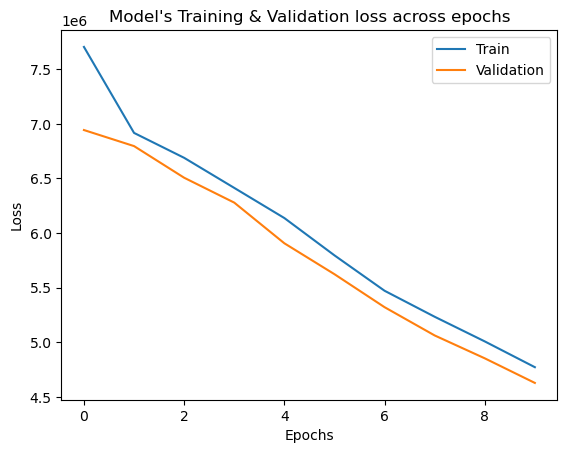

In [96]:
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.title("Model's Training & Validation loss across epochs")
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# MODEL 2

In [98]:
model_2 = Sequential()
model_2.add(Dense(150,input_dim = 30,activation="relu"))
model_2.add(Dense(150,activation="relu"))
model_2.add(Dense(150,activation="relu"))
model_2.add(Dense(150,activation="relu"))
model_2.add(Dense(150,activation="relu"))
model_2.add(Dense(1,activation = "linear"))
model_2.compile(
    optimizer='adam',
    loss='mse',
    metrics=[MeanAbsoluteError(name='mae')])
history_2 = model_2.fit(x_train,y_train, validation_data=(x_val,y_val),
epochs=15,batch_size=64)
print("Training & Validation:")
print("Training Loss:", history_2.history['loss'])
print("Validation Loss:", history_2.history['val_loss'])

print("Training MAE:", history_2.history['mae'])
print("Validation MAE:", history_2.history['val_mae'])

y_pred = model_2.predict(x_train)
r2 = r2_score(y_train, y_pred)
print(f"R² score training: {round(r2, 4)}")
y_pred = model_2.predict(x_val)
r2 = r2_score(y_val, y_pred)
print(f"R² score validation: {round(r2, 4)}")

print("Testing:")
result = model_2.evaluate(x_test,y_test)
for i in range(len(model_2.metrics_names)):
    print("Metric ",model_2.metrics_names[i],":",str(round(result[i],2)))
    
y_pred = model_2.predict(x_test)
r2 = r2_score(y_test, y_pred)
print(f"R² score: {round(r2, 4)}")

Epoch 1/15


C:\Users\aa\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9500/9500 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - loss: 8611969.0000 - mae: 2092.9272 - val_loss: 6930115.0000 - val_mae: 1839.5243
Epoch 2/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 6592228.5000 - mae: 1860.2653 - val_loss: 6052370.5000 - val_mae: 1790.3672
Epoch 3/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 6033025.0000 - mae: 1782.9869 - val_loss: 5670904.0000 - val_mae: 1713.3740
Epoch 4/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 5569520.5000 - mae: 1713.9163 - val_loss: 5184123.5000 - val_mae: 1653.8369
Epoch 5/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 5091894.5000 - mae: 1630.3885 - val_loss: 4531442.0000 - val_mae: 1525.8792
Epoch 6/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 4434592.5000 - mae: 1512.8286 - val_loss: 3647918.0000 - val_mae: 1370.2480
Epoch 7/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - loss: 3688556.2500 - mae: 1366.8326 - val_loss: 3121040.7500 - val_mae: 1245.1088
Epoch 8/15
9500/9500 ━━━━━━━━━━━━━━━━━

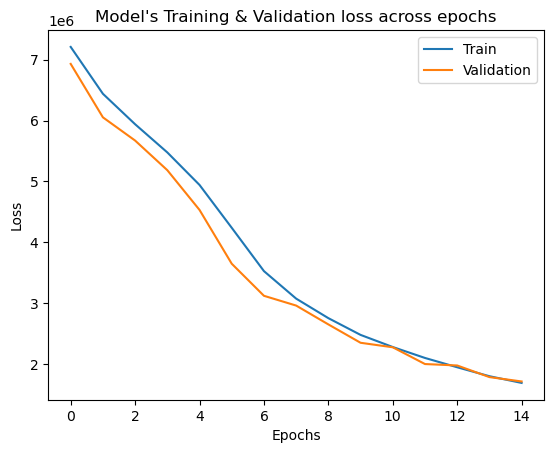

In [100]:
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title("Model's Training & Validation loss across epochs")
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# MODEL 3

In [103]:
model_3 = Sequential()
model_3.add(Dense(350,input_dim = 30,activation="relu"))
model_3.add(Dense(350,activation="relu"))
model_3.add(Dense(1,activation = "linear"))
model_3.compile(
    optimizer='adam',
    loss='mse',
    metrics=[MeanAbsoluteError(name='mae')])
history_3 = model_3.fit(x_train,y_train, validation_data=(x_val,
y_val),epochs=15,batch_size=64)
print("Training & Validation:")
print("Training Loss:", history_3.history['loss'])
print("Validation Loss:", history_3.history['val_loss'])

print("Training MAE:", history_3.history['mae'])
print("Validation MAE:", history_3.history['val_mae'])

y_pred = model_3.predict(x_train)
r2 = r2_score(y_train, y_pred)
print(f"R² score training: {round(r2, 4)}")
y_pred = model_3.predict(x_val)
r2 = r2_score(y_val, y_pred)
print(f"R² score validation: {round(r2, 4)}")

print("Testing:")
result = model_3.evaluate(x_test,y_test)
for i in range(len(model_3.metrics_names)):
    print("Metric ",model_3.metrics_names[i],":",str(round(result[i],2)))
    
y_pred = model_3.predict(x_test)
r2 = r2_score(y_test, y_pred)
print(f"R² score: {round(r2, 4)}")

Epoch 1/15


C:\Users\aa\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9500/9500 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - loss: 10589963.0000 - mae: 2316.4888 - val_loss: 7318008.5000 - val_mae: 1982.3234
Epoch 2/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - loss: 7331265.5000 - mae: 1973.6445 - val_loss: 7157323.5000 - val_mae: 1960.0956
Epoch 3/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - loss: 7215135.5000 - mae: 1952.4041 - val_loss: 7009548.5000 - val_mae: 1929.5619
Epoch 4/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - loss: 7059146.5000 - mae: 1931.2238 - val_loss: 6928861.5000 - val_mae: 1925.4973
Epoch 5/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - loss: 6943876.5000 - mae: 1914.6409 - val_loss: 6853244.5000 - val_mae: 1924.2814
Epoch 6/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - loss: 6912745.5000 - mae: 1907.9806 - val_loss: 6756150.5000 - val_mae: 1881.6868
Epoch 7/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - loss: 6766560.5000 - mae: 1886.8524 - val_loss: 6649081.0000 - val_mae: 1854.4426
Epoch 8/15
9500/9500 ━━━━━━━━━━━━━━━━

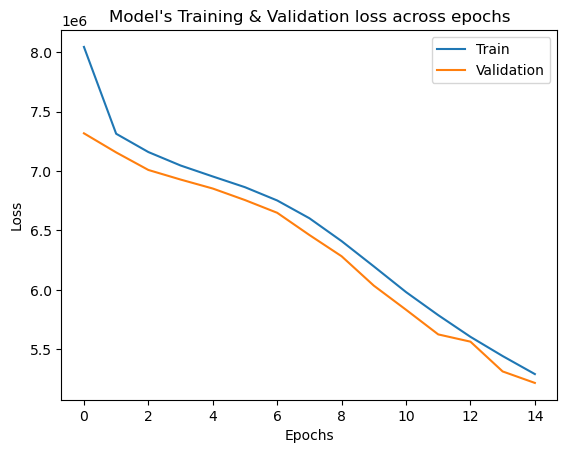

In [105]:
plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'])
plt.title("Model's Training & Validation loss across epochs")
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# MODEL 4

In [108]:
model_4 = Sequential([
    Input(shape=(30,)),
    Dense(350, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(350, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(350, activation='relu'),
    Dense(1, activation='linear')
])

model_4.compile(
    optimizer='adam',
    loss='mse',
    metrics=["mae"])
early_stop = EarlyStopping(
    monitor='val_loss',       
    patience=10,              
    restore_best_weights=True
)
history_4 = model_4.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop])
print("Training & Validation:")
print("Training Loss:", history_4.history['loss'])
print("Validation Loss:", history_4.history['val_loss'])

print("Training MAE:", history_4.history['mae'])
print("Validation MAE:", history_4.history['val_mae'])

y_pred = model_4.predict(x_train)
r2 = r2_score(y_train, y_pred)
print(f"R² score training: {round(r2, 4)}")
y_pred = model_4.predict(x_val)
r2 = r2_score(y_val, y_pred)
print(f"R² score validation: {round(r2, 4)}")

print("Testing:")
result = model_4.evaluate(x_test,y_test)
for i in range(len(model_4.metrics_names)):
    print("Metric ",model_4.metrics_names[i],":",str(round(result[i],2)))
    
y_pred = model_4.predict(x_test)
r2 = r2_score(y_test, y_pred)
print(f"R² score: {round(r2, 4)}")

Epoch 1/50
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - loss: 11806500.0000 - mae: 2452.0110 - val_loss: 6431702.5000 - val_mae: 1834.6309
Epoch 2/50
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - loss: 6766589.0000 - mae: 1889.7957 - val_loss: 6087193.5000 - val_mae: 1800.8643
Epoch 3/50
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - loss: 6421424.5000 - mae: 1843.6746 - val_loss: 5779350.5000 - val_mae: 1756.4301
Epoch 4/50
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - loss: 6147975.5000 - mae: 1805.3463 - val_loss: 5688462.5000 - val_mae: 1731.5775
Epoch 5/50
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - loss: 6057825.5000 - mae: 1787.1378 - val_loss: 5682282.5000 - val_mae: 1704.3644
Epoch 6/50
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - loss: 5885765.5000 - mae: 1761.3199 - val_loss: 5364922.5000 - val_mae: 1667.9255
Epoch 7/50
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - loss: 5757445.0000 - mae: 1739.8396 - val_loss: 5038163.0000 - val_mae: 1604.4080
Epoch 8/50
9500/9500 ━━━━━

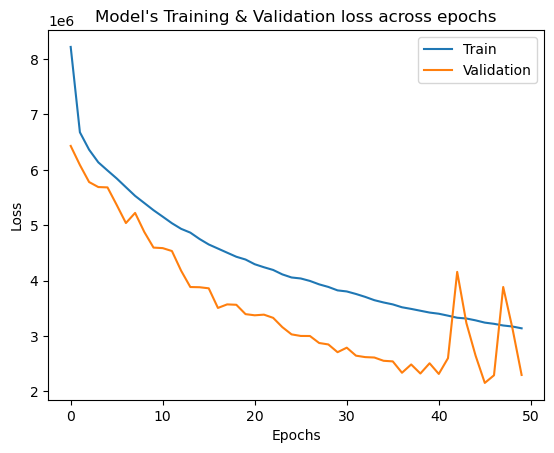

In [116]:
plt.plot(history_4.history['loss'])
plt.plot(history_4.history['val_loss'])
plt.title("Model's Training & Validation loss across epochs")
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# MODEL 5

In [118]:
model_5 = Sequential()
model_5.add(Dense(350,input_dim = 30,activation="relu"))
model_5.add(Dense(350,activation="relu"))
model_5.add(Dense(350,activation="relu"))
model_5.add(Dense(350,activation="relu"))
model_5.add(Dense(350,activation="relu"))
model_5.add(Dense(1,activation = "linear"))
model_5.compile(
    optimizer='adam',
    loss='mse',
    metrics=["mae"])
history_5 = model_5.fit(x_train,y_train, validation_data=(x_val,y_val),
epochs=15,batch_size=64)
print("Training & Validation:")
print("Training Loss:", history_5.history['loss'])
print("Validation Loss:", history_5.history['val_loss'])

print("Training MAE:", history_5.history['mae'])
print("Validation MAE:", history_5.history['val_mae'])

y_pred = model_5.predict(x_train)
r2 = r2_score(y_train, y_pred)
print(f"R² score training: {round(r2, 4)}")
y_pred = model_5.predict(x_val)
r2 = r2_score(y_val, y_pred)
print(f"R² score validation: {round(r2, 4)}")

print("Testing:")
result = model_5.evaluate(x_test,y_test)
for i in range(len(model_5.metrics_names)):
    print("Metric ",model_5.metrics_names[i],":",str(round(result[i],2)))
    
y_pred = model_5.predict(x_test)
r2 = r2_score(y_test, y_pred)
print(f"R² score: {round(r2, 4)}")

Epoch 1/15


C:\Users\aa\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9500/9500 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step - loss: 8067766.0000 - mae: 2035.6912 - val_loss: 6488213.5000 - val_mae: 1806.7599
Epoch 2/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - loss: 6313942.0000 - mae: 1817.2802 - val_loss: 5783653.0000 - val_mae: 1756.4010
Epoch 3/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 55s 6ms/step - loss: 5756187.5000 - mae: 1738.5499 - val_loss: 5428589.5000 - val_mae: 1692.1661
Epoch 4/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 50s 5ms/step - loss: 5355455.5000 - mae: 1666.6469 - val_loss: 4718553.0000 - val_mae: 1564.1959
Epoch 5/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - loss: 4642119.5000 - mae: 1545.0059 - val_loss: 4126582.2500 - val_mae: 1415.0359
Epoch 6/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 3914444.2500 - mae: 1397.0166 - val_loss: 3417046.5000 - val_mae: 1291.6196
Epoch 7/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 44s 5ms/step - loss: 3295437.0000 - mae: 1269.6442 - val_loss: 2868145.5000 - val_mae: 1194.6459
Epoch 8/15
9500/9500 ━━━━━━━━━━━━━━━━━

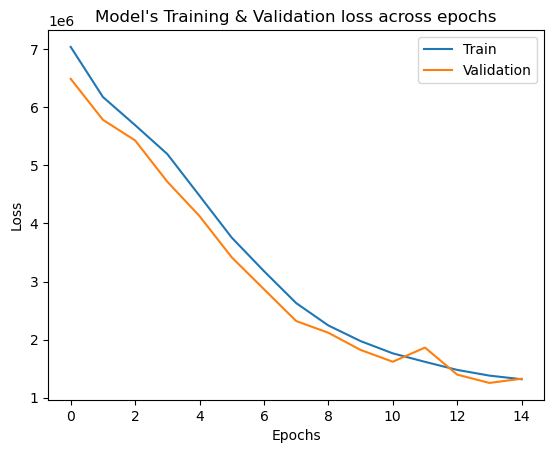

In [119]:
plt.plot(history_5.history['loss'])
plt.plot(history_5.history['val_loss'])
plt.title("Model's Training & Validation loss across epochs")
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# MODEL 6

In [121]:
model_6 = Sequential()
model_6.add(Dense(350, input_dim=30, activation="relu"))
model_6.add(Dropout(0.3))
model_6.add(Dense(256, activation="relu"))
model_6.add(Dropout(0.3))
model_6.add(Dense(128, activation="relu"))
model_6.add(Dense(64, activation="relu"))
model_6.add(Dense(1, activation="linear"))
model_6.compile(
    optimizer='adam',
    loss='mse',
    metrics=["mae"])
history_6 = model_6.fit(x_train,y_train, validation_data=(x_val,y_val),
epochs=15,batch_size=64)
print("Training & Validation:")
print("Training Loss:", history_6.history['loss'])
print("Validation Loss:", history_6.history['val_loss'])

print("Training MAE:", history_6.history['mae'])
print("Validation MAE:", history_6.history['val_mae'])

y_pred = model_6.predict(x_train)
r2 = r2_score(y_train, y_pred)
print(f"R² score training: {round(r2, 4)}")
y_pred = model_6.predict(x_val)
r2 = r2_score(y_val, y_pred)
print(f"R² score validation: {round(r2, 4)}")

print("Testing:")
result = model_6.evaluate(x_test,y_test)
for i in range(len(model_6.metrics_names)):
    print("Metric ",model_6.metrics_names[i],":",str(round(result[i],2)))
    
y_pred = model_6.predict(x_test)
r2 = r2_score(y_test, y_pred)
print(f"R² score: {round(r2, 4)}")

C:\Users\aa\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - loss: 9197986.0000 - mae: 2164.7017 - val_loss: 6881883.5000 - val_mae: 1946.7157
Epoch 2/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - loss: 7116955.5000 - mae: 1937.1324 - val_loss: 6622512.0000 - val_mae: 1854.7977
Epoch 3/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 6890033.0000 - mae: 1908.6938 - val_loss: 6383522.5000 - val_mae: 1853.6617
Epoch 4/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 6723934.5000 - mae: 1883.7163 - val_loss: 6209594.0000 - val_mae: 1790.4320
Epoch 5/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 6544541.5000 - mae: 1859.3280 - val_loss: 6100809.5000 - val_mae: 1778.8488
Epoch 6/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 6374679.0000 - mae: 1833.9135 - val_loss: 5843390.0000 - val_mae: 1738.4703
Epoch 7/15
9500/9500 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 6171234.5000 - mae: 1803.6283 - val_loss: 5676353.0000 - val_mae: 1733.5791
Epoch 8/15
9500/9500 ━━━━━━

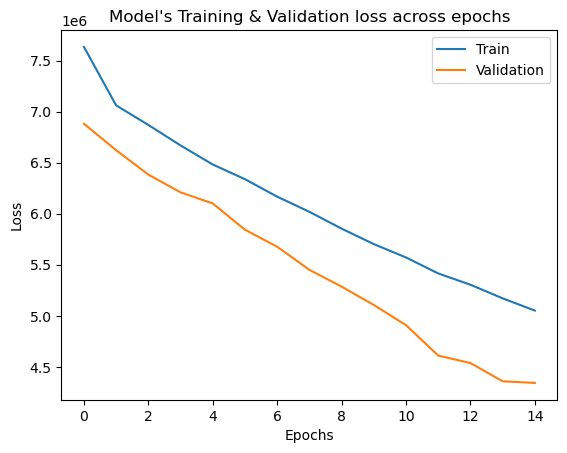

In [123]:
plt.plot(history_6.history['loss'])
plt.plot(history_6.history['val_loss'])
plt.title("Model's Training & Validation loss across epochs")
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

#	Conclusion:
The best model for sales forecasting was Model 5 with the least error, as the training, validation and testing data had close results. To understand more about model building, training and results, see the code. There is a graph showing the results with more explanation.
